## State preparation of flat band state from a localized state

### Imports

In [1]:
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.bosehubbard.utils.lieb import lieb_lattice,occupation_number,lattice_visualization
from typing import List


### Data

Chemical potential Hamiltonians $H_{\mu_a}$,$H_{\mu_b}$,$H_{\mu_c}$ and the coupling one $H_J$

In [223]:
linear_dimension:int=3
hopping_energy:float=0.
omegas_abc=np.zeros((3,3*linear_dimension**2))
for i in range(0,omegas_abc.shape[-1],3):
    omegas_abc[0,i]=1.
    omegas_abc[1,i+1]=1.
    omegas_abc[2,i+2]=1.

links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)
u:float = 0

hamiltonians_abc=[]
for omegas in omegas_abc:
    model = bh.Model(omegas, links, u)
    model_single_particle=model.numbersector(1)
    hamiltonian=model_single_particle.hamiltonian
    hamiltonians_abc.append(hamiltonian)
    print(hamiltonian)
    
omegas=np.zeros((3*linear_dimension**2))
hopping_energy=1.
links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)

model = bh.Model(omegas, links, u)
model_single_particle=model.numbersector(1)
hamiltonian_j=model_single_particle.hamiltonian
print(hamiltonian_j)

9
(27, 27)
  (0, 0)	1.0
  (3, 3)	1.0
  (6, 6)	1.0
  (9, 9)	1.0
  (12, 12)	1.0
  (15, 15)	1.0
  (18, 18)	1.0
  (21, 21)	1.0
  (24, 24)	1.0
(27, 27)
  (1, 1)	1.0
  (4, 4)	1.0
  (7, 7)	1.0
  (10, 10)	1.0
  (13, 13)	1.0
  (16, 16)	1.0
  (19, 19)	1.0
  (22, 22)	1.0
  (25, 25)	1.0
(27, 27)
  (2, 2)	1.0
  (5, 5)	1.0
  (8, 8)	1.0
  (11, 11)	1.0
  (14, 14)	1.0
  (17, 17)	1.0
  (20, 20)	1.0
  (23, 23)	1.0
  (26, 26)	1.0
9
(27, 27)
  (0, 1)	1.0
  (1, 0)	1.0
  (1, 2)	1.0
  (1, 9)	1.0
  (2, 1)	1.0
  (2, 4)	1.0
  (3, 4)	1.0
  (4, 2)	1.0
  (4, 3)	1.0
  (4, 5)	1.0
  (4, 12)	1.0
  (5, 4)	1.0
  (5, 7)	1.0
  (6, 7)	1.0
  (7, 5)	1.0
  (7, 6)	1.0
  (7, 8)	1.0
  (7, 15)	1.0
  (8, 7)	1.0
  (9, 1)	1.0
  (9, 10)	1.0
  (10, 9)	1.0
  (10, 11)	1.0
  (10, 18)	1.0
  (11, 10)	1.0
  :	:
  (15, 16)	1.0
  (16, 14)	1.0
  (16, 15)	1.0
  (16, 17)	1.0
  (16, 24)	1.0
  (17, 16)	1.0
  (18, 10)	1.0
  (18, 19)	1.0
  (19, 18)	1.0
  (19, 20)	1.0
  (20, 19)	1.0
  (20, 22)	1.0
  (21, 13)	1.0
  (21, 22)	1.0
  (22, 20)	1.0
  (22, 21

In [224]:
psi_initial=np.zeros(hamiltonian.shape[0])
#psi0=np.zeros(linear_dimension)


index=12 # random initial site mu_a
psi_initial[index]=1.
psi_initial=psi_initial/np.linalg.norm(psi_initial)

### Evolution: step 1 -> separate the spectrum by using different chemical potentials

#### $\mu_c(t)$

State initialization

In [225]:
psi0=psi_initial.copy()

Hyperparameters

In [226]:
nstep=1000
tf=10.
time_sp=np.linspace(0.,tf,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))

initial_mu=1.
final_mu_b=0.
final_mu_c=2.

0it [01:16, ?it/s]


Drivings

In [227]:
mu_a=initial_mu
mu_b=initial_mu
mu_c=initial_mu+time_sp*(final_mu_c-initial_mu)/tf

Time evolution

In [228]:
psi_mu=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_mu_t=psi0.copy()
e_ave=np.zeros((nstep))

for i,t in enumerate(time_sp):
    
    hamiltonian_t=hamiltonians_abc[0]*mu_a+hamiltonians_abc[1]*mu_b+hamiltonians_abc[2]*mu_c[i]
    psi_mu[i,:]=psi_mu_t  
    e_ave[i]=np.conj(psi_mu_t).T.dot(hamiltonian_t.dot(psi_mu_t))
    psi_mu_t=expmv(dt,-1j*hamiltonian_t,psi_mu_t)

/tmp/ipykernel_1863518/3220395996.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  e_ave[i]=np.conj(psi_mu_t).T.dot(hamiltonian_t.dot(psi_mu_t))


Compute the fidelity

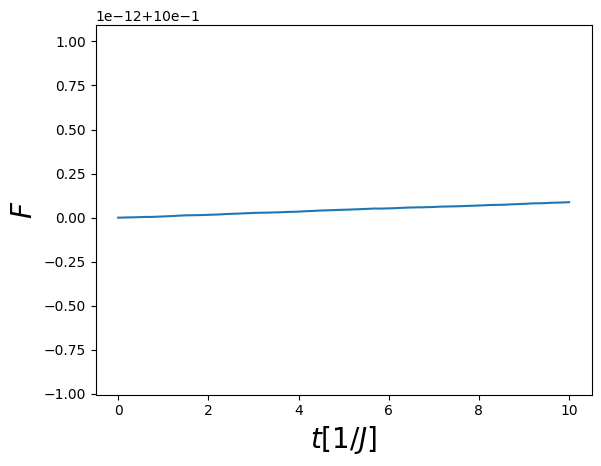

1.000000000000088
1.000000000000088


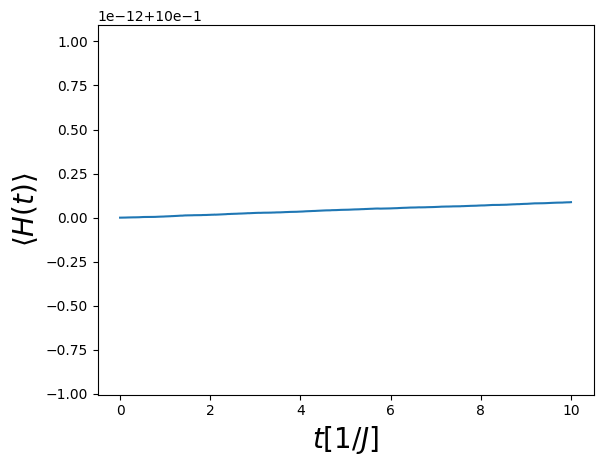

In [229]:
fidelity_single_particle:np.ndarray=np.real((np.einsum('ti,i->t',np.conjugate(psi_mu),psi0)))**2+np.imag((np.einsum('ti,i->t',np.conjugate(psi_mu),psi0)))**2
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$F$',fontsize=20)
plt.plot(time_sp,fidelity_single_particle)
plt.show()
print(fidelity_single_particle[-1])
plt.plot(time_sp,e_ave)
print(e_ave[-1])
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$\langle H(t) \rangle$',fontsize=20)
plt.show()

Compute the occupation number

(27, 27)


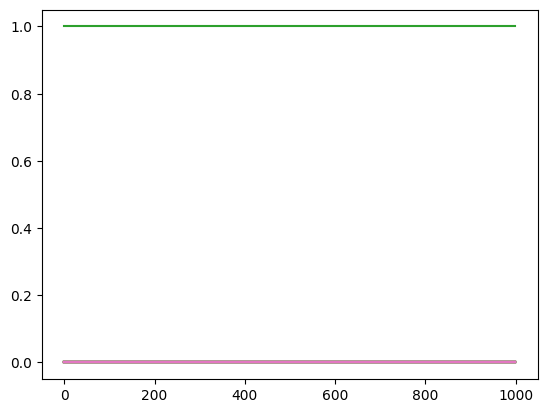

[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


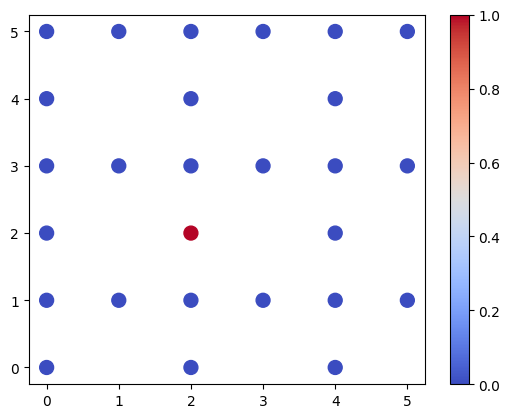

In [230]:
single_particle_n=occupation_number(psi=psi_mu,basis=model_single_particle.basis.vs,size=psi_mu_t.shape[-1])
for i in range(single_particle_n.shape[1]):
    plt.plot(single_particle_n[:,i])
plt.show()
lattice_visualization(n=single_particle_n[-1,:],linear_dimension=linear_dimension)

### $\mu_b(t)$

State initialization

In [231]:
psi0=psi_mu[-1]

Hyperparameters

In [232]:
nstep=1000
tf=10.
time_sp=np.linspace(0.,tf,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))

initial_mu_c=2.
initial_mu=1.
final_mu_b=0.


0it [00:14, ?it/s]


Drivings

In [233]:
mu_a=initial_mu
mu_c=initial_mu_c
mu_b=initial_mu+time_sp*(final_mu_b-initial_mu)/tf

Time evolution

In [235]:
psi_mu=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_mu_t=psi0.copy()
e_ave=np.zeros((nstep))

for i,t in enumerate(time_sp):
    
    hamiltonian_t=hamiltonians_abc[0]*mu_a+hamiltonians_abc[1]*mu_b[i]+hamiltonians_abc[2]*mu_c
    psi_mu[i,:]=psi_mu_t  
    e_ave[i]=np.conj(psi_mu_t).T.dot(hamiltonian_t.dot(psi_mu_t))
    psi_mu_t=expmv(dt,-1j*hamiltonian_t,psi_mu_t)

/tmp/ipykernel_1863518/3036171644.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  e_ave[i]=np.conj(psi_mu_t).T.dot(hamiltonian_t.dot(psi_mu_t))


Compute the fidelity

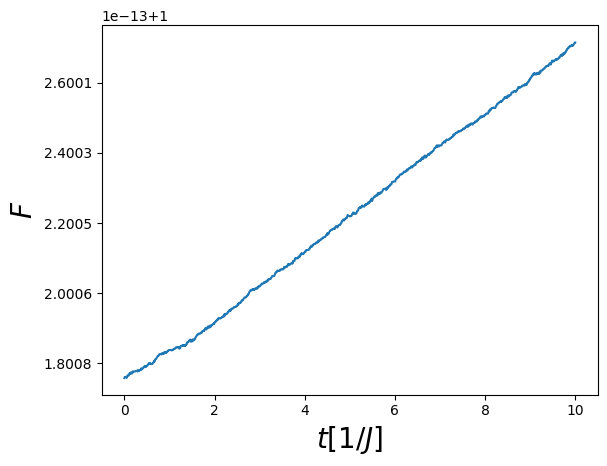

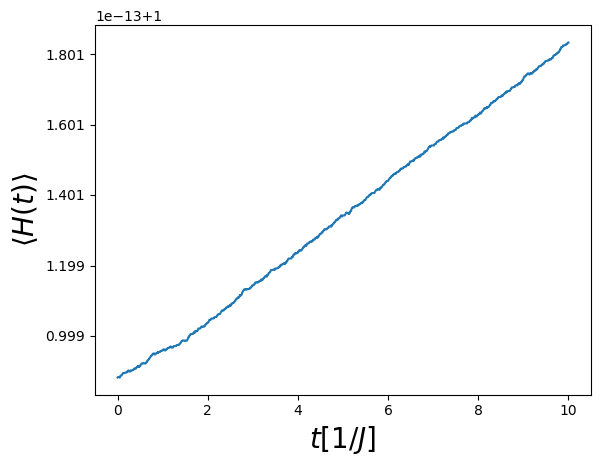

In [236]:
fidelity_single_particle:np.ndarray=np.real((np.einsum('ti,i->t',np.conjugate(psi_mu),psi0)))**2+np.imag((np.einsum('ti,i->t',np.conjugate(psi_mu),psi0)))**2
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$F$',fontsize=20)
plt.plot(time_sp,fidelity_single_particle)
plt.show()

plt.plot(time_sp,e_ave)
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$\langle H(t) \rangle$',fontsize=20)
plt.show()

Occupation Number

(27, 27)
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


/home/ecosta/glasgow_project/src/bosehubbard/utils/lieb.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  n[:, i] = np.einsum("tj,tj,j->t", np.conjugate(psi), psi, basis[:, i])


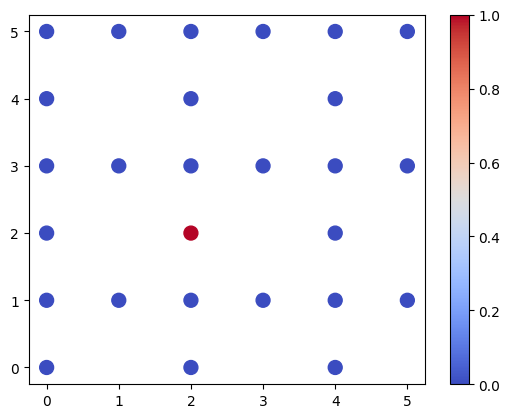

In [237]:
single_particle_n=occupation_number(psi=psi_mu,basis=model_single_particle.basis.vs,size=psi_mu_t.shape[-1])

lattice_visualization(n=single_particle_n[-1,:],linear_dimension=linear_dimension)

### $J(t)$

State initialization

In [269]:
psi0=psi_mu[-1]

Hyperparameters

In [270]:
nstep=10000
tf=200.
time_sp=np.linspace(0.,tf,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))



0it [13:26, ?it/s]


Drivings

In [271]:
jf=1.
mu_a=1.
mu_c=2.
mu_b=0.
j_t=time_sp*(jf/tf)

Time evolution

In [272]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_t=psi0.copy()
e_ave=np.zeros((nstep))
spectrum=np.zeros((nstep,15))
for i,t in enumerate(time_sp):
    
    hamiltonian_t=hamiltonians_abc[0]*mu_a+hamiltonians_abc[1]*mu_b+hamiltonians_abc[2]*mu_c+hamiltonian_j*j_t[i]
    e_values,_=scipy.sparse.linalg.eigsh(hamiltonian_t,k=15,which='SM')
    spectrum[i]=e_values
    psi[i,:]=psi_t  
    e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))
    psi_t=expmv(dt,-1j*hamiltonian_t,psi_t)

/tmp/ipykernel_1863518/264874992.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))


Compute the fidelity

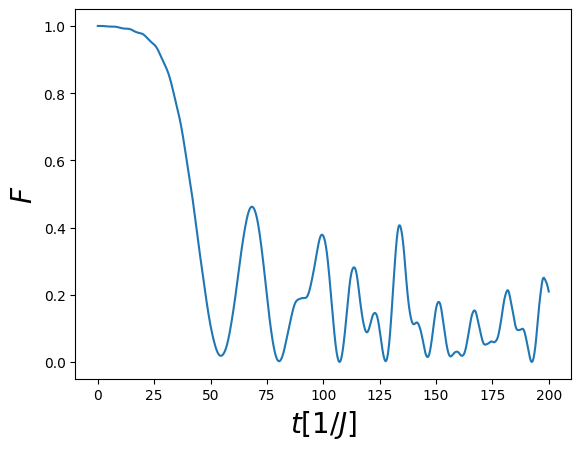

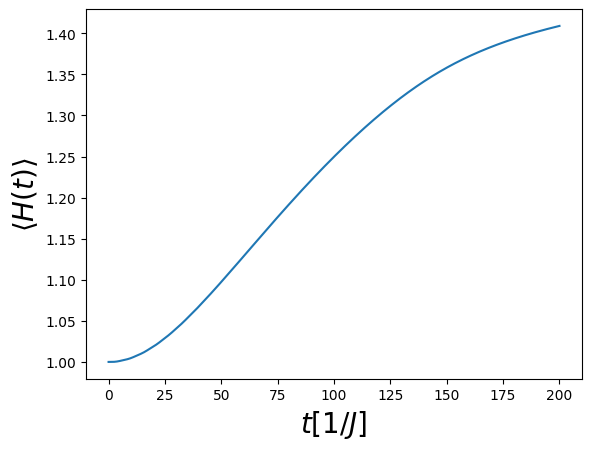

In [273]:
fidelity_single_particle:np.ndarray=np.real((np.einsum('ti,i->t',np.conjugate(psi),psi0)))**2+np.imag((np.einsum('ti,i->t',np.conjugate(psi),psi0)))**2
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$F$',fontsize=20)
plt.plot(time_sp,fidelity_single_particle)
plt.show()

plt.plot(time_sp,e_ave)
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$\langle H(t) \rangle$',fontsize=20)
plt.show()



See the spectrum

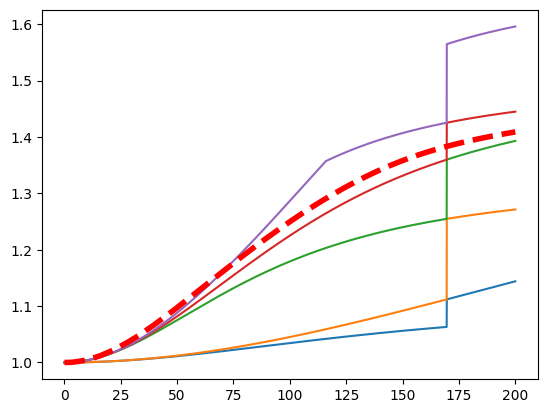

In [275]:
for i in range(10,spectrum.shape[-1]):
    plt.plot(time_sp,spectrum[:,i],label=f'k={i}')
plt.plot(time_sp,e_ave,color='red',linestyle='--',linewidth=4)
plt.show()

Occupation Number

(27, 27)
[[0.03226045 0.05736188 0.02156549]
 [0.01984879 0.21006886 0.12892357]
 [0.06381314 0.00976699 0.08856616]]
[[0.00353658 0.00039444 0.00117126]
 [0.00106249 0.00418848 0.01200803]
 [0.01246117 0.00645196 0.00483256]]
[[0.02864145 0.00380849 0.0298829 ]
 [0.04435309 0.00918311 0.14255791]
 [0.00893435 0.00477801 0.04957839]]


/home/ecosta/glasgow_project/src/bosehubbard/utils/lieb.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  n[:, i] = np.einsum("tj,tj,j->t", np.conjugate(psi), psi, basis[:, i])


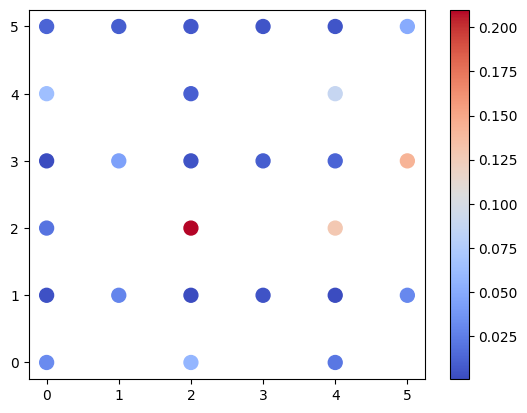

In [276]:
single_particle_n=occupation_number(psi=psi,basis=model_single_particle.basis.vs,size=psi_t.shape[-1])

lattice_visualization(n=single_particle_n[-1,:],linear_dimension=linear_dimension)

#### $J(t)$

State initialization

In [280]:
psi0=psi[-1]

Hyperparameters

In [281]:
nstep=10000
tf=200.
time_sp=np.linspace(0.,tf,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))



0it [01:43, ?it/s]


Drivings

In [282]:
jf=1.
mu_final=1.
mu_a=1.
mu_c=2.+time_sp*((mu_final-2)/tf)
mu_b=0.+time_sp*((mu_final)/tf)
j_t=jf

Time evolution

In [283]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
psi_t=psi0.copy()
e_ave=np.zeros((nstep))
e_values=np.zeros((nstep,15))

for i,t in enumerate(time_sp):
    
    hamiltonian_t=hamiltonians_abc[0]*mu_a+hamiltonians_abc[1]*mu_b[i]+hamiltonians_abc[2]*mu_c[i]+hamiltonian_j*j_t
    e_values,_=scipy.sparse.linalg.eigsh(hamiltonian_t,k=15)
    spectrum[i]=e_values
    psi[i,:]=psi_t  
    e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))
    psi_t=expmv(dt,-1j*hamiltonian_t,psi_t)

/tmp/ipykernel_1863518/154950075.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))


Spectrum

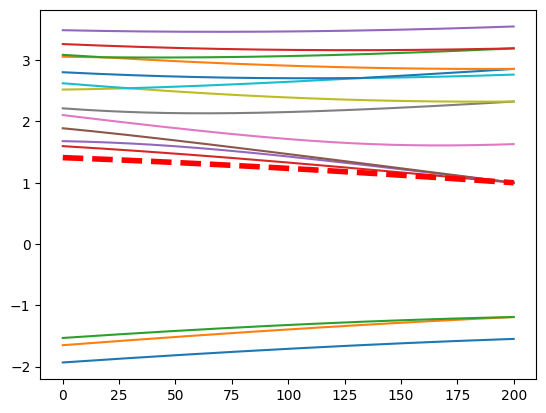

In [284]:
for i in range(spectrum.shape[-1]):
    plt.plot(time_sp,spectrum[:,i],label=f'k={i}')
plt.plot(time_sp,e_ave,color='red',linestyle='--',linewidth=4)
plt.show()

Compute the fidelity

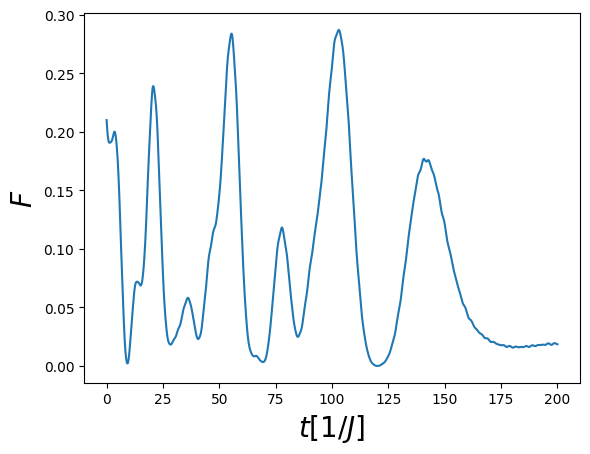

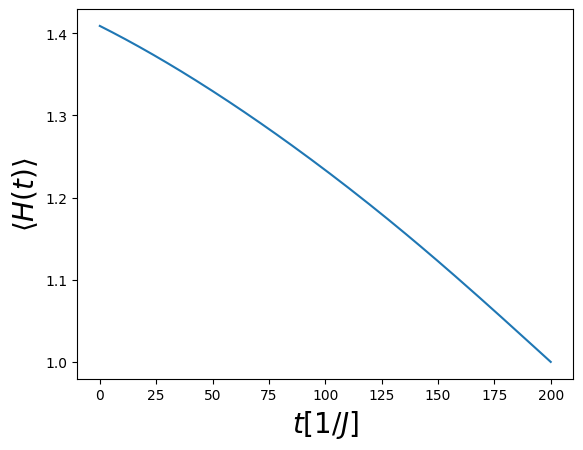

In [285]:
fidelity_single_particle:np.ndarray=np.real((np.einsum('ti,i->t',np.conjugate(psi),psi_initial)))**2+np.imag((np.einsum('ti,i->t',np.conjugate(psi),psi_initial)))**2
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$F$',fontsize=20)
plt.plot(time_sp,fidelity_single_particle)
plt.show()

plt.plot(time_sp,e_ave)
plt.xlabel(r'$t[1/J]$',fontsize=20)
plt.ylabel(r'$\langle H(t) \rangle$',fontsize=20)
plt.show()



### Result of the Procedure

We compute the eigenvectors of the hamiltonian

In [288]:
spectrum,psi_n=scipy.sparse.linalg.eigsh(hamiltonian_t,k=25)

print(spectrum)
psi_flat_band=psi_n[:,spectrum==1]
print(psi_flat_band.shape)

[-1.54832478 -1.19133241 -1.19133241 -0.8560824  -0.8560824  -0.76349547
  0.37061575  1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.62938425  2.32401677
  2.32401677  2.76349547  2.8560824   2.8560824   3.19133241  3.19133241
  3.54832478]
(27, 9)


We check the fidelity into the flat band subspace this should tell you the fidelity of reaching a flat band state

In [289]:
c_n=np.einsum('in,i->n',np.conj(psi_flat_band),psi[-1])
fidelity=np.sum(np.conj(c_n)*c_n)
print(fidelity)



(0.999944206239529+0j)


Occupation Number

(27, 27)
[[0.05490696 0.08560901 0.00671402]
 [0.06796047 0.01849341 0.0176787 ]
 [0.06980782 0.14825525 0.02897716]]
[[4.90221267e-06 2.64932968e-06 2.87032398e-07]
 [6.67684873e-06 5.34441043e-06 1.05280297e-06]
 [9.90517520e-07 2.23135998e-06 1.27017811e-06]]
[[0.02109334 0.00452771 0.00264436]
 [0.19781963 0.01829912 0.1660852 ]
 [0.07050107 0.01447459 0.0061268 ]]


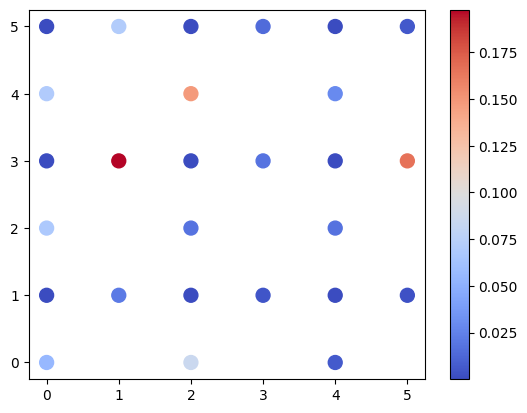

In [290]:
single_particle_n=occupation_number(psi=psi,basis=model_single_particle.basis.vs,size=psi_t.shape[-1])

lattice_visualization(n=single_particle_n[-1,:],linear_dimension=linear_dimension)

## Complete Dynamics

#### Imports

In [3]:
import src.bosehubbard.bosehubbard as bh
import numpy as np
import scipy
import scipy.sparse as sparse
from pyexpokit import expmv
from tqdm import tqdm
import matplotlib.pyplot as plt
from src.bosehubbard.utils.lieb import lieb_lattice,occupation_number,lattice_visualization
from typing import List


#### Initialization

In [54]:
linear_dimension:int=7
hopping_energy:float=0.
omegas_abc=np.zeros((3,3*linear_dimension**2))
for i in range(0,omegas_abc.shape[-1],3):
    omegas_abc[0,i]=1.
    omegas_abc[1,i+1]=1.
    omegas_abc[2,i+2]=1.

links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)
u:float = 0

hamiltonians_abc=[]
for omegas in omegas_abc:
    model = bh.Model(omegas, links, u)
    model_single_particle=model.numbersector(1)
    hamiltonian=model_single_particle.hamiltonian
    hamiltonians_abc.append(hamiltonian)
    print(hamiltonian)
    
omegas=np.zeros((3*linear_dimension**2))
hopping_energy=1.
links:List=lieb_lattice(hopping_value=hopping_energy,linear_dimension=linear_dimension)

model = bh.Model(omegas, links, u)
model_single_particle=model.numbersector(1)
hamiltonian_j=model_single_particle.hamiltonian
print(hamiltonian_j)

49
(147, 147)
  (0, 0)	1.0
  (3, 3)	1.0
  (6, 6)	1.0
  (9, 9)	1.0
  (12, 12)	1.0
  (15, 15)	1.0
  (18, 18)	1.0
  (21, 21)	1.0
  (24, 24)	1.0
  (27, 27)	1.0
  (30, 30)	1.0
  (33, 33)	1.0
  (36, 36)	1.0
  (39, 39)	1.0
  (42, 42)	1.0
  (45, 45)	1.0
  (48, 48)	1.0
  (51, 51)	1.0
  (54, 54)	1.0
  (57, 57)	1.0
  (60, 60)	1.0
  (63, 63)	1.0
  (66, 66)	1.0
  (69, 69)	1.0
  (72, 72)	1.0
  (75, 75)	1.0
  (78, 78)	1.0
  (81, 81)	1.0
  (84, 84)	1.0
  (87, 87)	1.0
  (90, 90)	1.0
  (93, 93)	1.0
  (96, 96)	1.0
  (99, 99)	1.0
  (102, 102)	1.0
  (105, 105)	1.0
  (108, 108)	1.0
  (111, 111)	1.0
  (114, 114)	1.0
  (117, 117)	1.0
  (120, 120)	1.0
  (123, 123)	1.0
  (126, 126)	1.0
  (129, 129)	1.0
  (132, 132)	1.0
  (135, 135)	1.0
  (138, 138)	1.0
  (141, 141)	1.0
  (144, 144)	1.0
(147, 147)
  (1, 1)	1.0
  (4, 4)	1.0
  (7, 7)	1.0
  (10, 10)	1.0
  (13, 13)	1.0
  (16, 16)	1.0
  (19, 19)	1.0
  (22, 22)	1.0
  (25, 25)	1.0
  (28, 28)	1.0
  (31, 31)	1.0
  (34, 34)	1.0
  (37, 37)	1.0
  (40, 40)	1.0
  (43, 43)	1.0

Initial and final values of the parameters

In [55]:
mu_a_initial=mu_b_initial=mu_c_initial=1.
mu_b_final=0. 
mu_c_final=2.
j_initial=0. 
j_final=1.

Initial state

In [68]:
psi0=np.zeros(hamiltonian.shape[0])
#psi0=np.zeros(linear_dimension)


index=3*(4+3*linear_dimension) # random initial site mu_a 3*(i+j*linear_dimension)
psi0[index]=1.
psi0=psi0/np.linalg.norm(psi0)

Time

In [81]:
nstep=8000
tf=80.

t_j_initial=5
t_j_final=55



time_sp=np.linspace(0.,tf,nstep)
dt=time_sp[1]-time_sp[0]
t_bar=tqdm(enumerate(time_sp))



0it [07:54, ?it/s]


Drivings

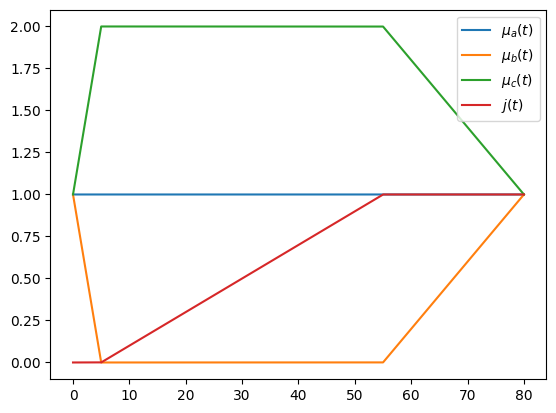

In [82]:
mu_a=mu_a_initial*np.ones((nstep))
mu_b=mu_b_initial*np.ones((nstep))
mu_b[:int(t_j_initial/dt)]=mu_b_initial+(time_sp[:int(t_j_initial/dt)]-time_sp[0])*((mu_b_final-mu_b_initial)/(time_sp[int(t_j_initial/dt)]-time_sp[0]))
mu_b[int(t_j_initial/dt):int(t_j_final/dt)]=mu_b_final
mu_b[int(t_j_final/dt):]=mu_b_final+(time_sp[int(t_j_final/dt):]-time_sp[int(t_j_final/dt)])*((-1*mu_b_final+mu_b_initial)/(time_sp[-1]-time_sp[int(t_j_final/dt)]))

mu_c=mu_c_initial*np.ones((nstep))
mu_c[:int(t_j_initial/dt)]=mu_c_initial+(time_sp[:int(t_j_initial/dt)]-time_sp[0])*((mu_c_final-mu_c_initial)/(time_sp[int(t_j_initial/dt)]-time_sp[0]))
mu_c[int(t_j_initial/dt):int(t_j_final/dt)]=mu_c_final
mu_c[int(t_j_final/dt):]=mu_c_final+(time_sp[int(t_j_final/dt):]-time_sp[int(t_j_final/dt)])*((mu_c_initial-mu_c_final)/(time_sp[-1]-time_sp[int(t_j_final/dt)]))
j=np.zeros(nstep)
j[int(t_j_initial/dt):int(t_j_final/dt)]=j_initial+(time_sp[int(t_j_initial/dt):int(t_j_final/dt)]-time_sp[int(t_j_initial/dt)])*((j_final-j_initial)/(time_sp[int(t_j_final/dt)]-time_sp[int(t_j_initial/dt)]))
j[int(t_j_final/dt):]=j_final
plt.plot(time_sp,mu_a,label=r'$\mu_a(t)$')
plt.plot(time_sp,mu_b,label=r'$\mu_b(t)$')
plt.plot(time_sp,mu_c,label=r'$\mu_c(t)$')
plt.plot(time_sp,j,label=r'$j(t)$')
plt.legend()
plt.show()

#### Evolution

In [83]:
psi=np.zeros((nstep,psi0.shape[0]),dtype=np.complex128)
spectrum=np.zeros((nstep,3*(linear_dimension**2)-1),dtype=np.float64)
psi_t=psi0.copy()
e_ave=np.zeros((nstep))
e_values=np.zeros((nstep,3*(linear_dimension**2)-1))

for i,t in enumerate(time_sp):
    
    hamiltonian_t=hamiltonians_abc[0]*mu_a[i]+hamiltonians_abc[1]*mu_b[i]+hamiltonians_abc[2]*mu_c[i]+hamiltonian_j*j[i]
    #e_values,_=scipy.sparse.linalg.eigsh(hamiltonian_t,k=3*(linear_dimension**2)-1)
    #spectrum[i]=e_values
    psi[i,:]=psi_t  
    e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))
    psi_t=expmv(dt,-1j*hamiltonian_t,psi_t)

/tmp/ipykernel_2709645/1119538497.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  e_ave[i]=np.conj(psi_t).T.dot(hamiltonian_t.dot(psi_t))


Fidelity in the Flat band subspace

In [84]:
spectrum_fb,psi_n=scipy.sparse.linalg.eigsh(hamiltonian_t,k=3*(linear_dimension)**2-1)

print(spectrum_fb)
# condition to take spectrum==1
idx=(spectrum_fb<1.00001) 
psi_flat_band=psi_n[:,idx]
psi_flat_band=psi_flat_band[:,spectrum_fb[idx]>0.9999]
###

print(psi_flat_band.shape)

[-1.76661921 -1.67681754 -1.67681754 -1.58389675 -1.53872505 -1.53872505
 -1.44055223 -1.44055223 -1.37023923 -1.37023923 -1.28824561 -1.26477467
 -1.26477467 -1.19706416 -1.19706416 -1.09975643 -1.09975643 -1.0828493
 -1.0828493  -1.05159863 -1.05159863 -0.96743379 -0.96743379 -0.92878906
 -0.92878906 -0.90211303 -0.90211303 -0.89258716 -0.83901224 -0.83901224
 -0.73205081 -0.73205081 -0.67061159 -0.67061159 -0.63148362 -0.63148362
 -0.47407906 -0.47407906 -0.41421356 -0.35449174 -0.35449174 -0.1755705
 -0.1755705  -0.02161871  0.12596795  0.34756547  0.34756547  0.70434886
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.

In [85]:
c_n=np.einsum('in,i->n',np.conj(psi_flat_band),psi[-1])
fidelity=np.sum(np.conj(c_n)*c_n)
print(fidelity)

(0.9817127531135402+0j)


Occupation number

(147, 147)
[[0.01728119 0.00456866 0.01092653 0.01630805 0.034963   0.01021496
  0.01985855]
 [0.00610907 0.00515287 0.00010576 0.00542302 0.08969292 0.01735698
  0.00142012]
 [0.00451027 0.00289993 0.002323   0.00285722 0.0115124  0.0020106
  0.00193499]
 [0.00464229 0.00119745 0.00545804 0.00415986 0.01084572 0.0136656
  0.00413434]
 [0.03026671 0.00745274 0.00222734 0.00030762 0.00747305 0.02491102
  0.0070729 ]
 [0.0040862  0.01106695 0.00142636 0.00615493 0.00640684 0.00078107
  0.01093232]
 [0.00183463 0.01943789 0.00806634 0.00756676 0.00942082 0.01772896
  0.0150752 ]]
[[5.41851476e-04 4.47257961e-04 4.22021879e-04 3.93714847e-04
  3.13208557e-04 1.52845456e-04 2.25492967e-05]
 [1.16626354e-04 1.42354433e-04 1.10897473e-04 1.00847224e-04
  1.30361054e-04 5.48624018e-05 6.05423553e-06]
 [3.36557799e-05 7.33906462e-05 6.86630499e-05 5.70813538e-05
  5.53057542e-05 4.29745779e-05 1.17050099e-05]
 [2.11004647e-04 2.25335859e-04 3.00290354e-04 2.09485908e-04
  6.61689120e-05 1.15454

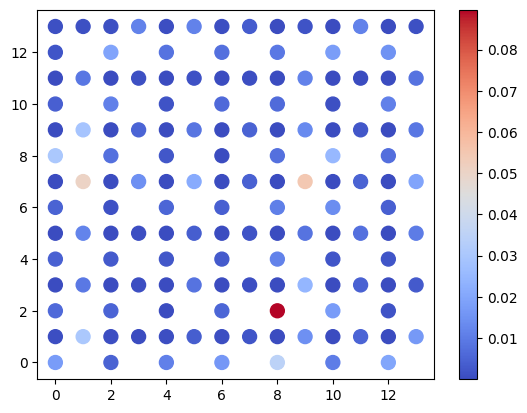

In [86]:
single_particle_n=occupation_number(psi=psi,basis=model_single_particle.basis.vs,size=psi_t.shape[-1])

lattice_visualization(n=single_particle_n[-1,:],linear_dimension=linear_dimension)